# EcoVision | Waste Classification

A complete image-classification workflow: inspect the dataset, prepare stratified splits,
train a pretrained ResNet18, evaluate the fine-tuned model, and export it for the application.

| Project detail | Configuration |
| :--- | :--- |
| Task | Single-image classification across 10 waste categories |
| Model | ResNet18 with pretrained ImageNet weights |
| Input | RGB image, 224 × 224 pixels |
| Dataset split | 70% train / 15% validation / 15% test |
| Training stages | 1 preliminary epoch → 5 classifier epochs → 3 fine-tuning epochs |



---

### Notebook Guide

| Section | Purpose |
| :--- | :--- |
| [01 · Environment & Setup](#setup) | Imports, dataset location, execution notes |
| [02 · Dataset Overview](#dataset-overview) | Available classes and class distribution |
| [03 · Image Quality Audit](#image-quality) | Dimensions, unusual sizes, corruption, duplicates |
| [04 · Visual Inspection](#visual-inspection) | Representative images from each class |
| [05 · Stratified Data Splits](#data-splits) | Image manifest and balanced train/validation/test sets |
| [06 · Preprocessing & Data Loaders](#preprocessing) | Augmentation, normalization, dataset, batches |
| [07 · ResNet18 & Optimization](#model-setup) | Pretrained model, classifier head, loss, optimizer |
| [08 · Classifier Training](#classifier-training) | Preliminary pass, training history, learning curves |
| [09 · Fine-Tuning](#fine-tuning) | Train the final residual block and classification head |
| [10 · Test Evaluation](#test-evaluation) | Accuracy, per-class metrics, confusion matrix |
| [11 · Export for the Application](#export) | Final model weights and class mapping |
| [Saved Results Summary](#results-summary) | Key metrics from the existing outputs |

<a id="setup"></a>

## 01 | Environment & Setup




In [ ]:

from collections import defaultdict
import hashlib
from pathlib import Path
import random

import numpy as np
import pandas as pd
from PIL import Image


import matplotlib.pyplot as plt


# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


data_path = Path("../data/original")

<a id="dataset-overview"></a>

## 02 | Dataset Overview


Start by inspecting class folders, counting supported image files, and plotting their distribution.

In [2]:
for item in data_path.iterdir():
    if item.is_dir():
        print(item)

..\data\original\battery
..\data\original\biological
..\data\original\cardboard
..\data\original\clothes
..\data\original\glass
..\data\original\metal
..\data\original\paper
..\data\original\plastic
..\data\original\shoes
..\data\original\trash


### Class Counts

Count image files per class and report the total dataset size.

In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

class_counts = {}

for class_dir in sorted(data_path.iterdir()):
    if class_dir.is_dir():

        images = [
            file
            for file in class_dir.rglob("*")
            if file.is_file() and file.suffix.lower() in image_extensions
        ]

        class_counts[class_dir.name] = len(images)

        print(f"{class_dir.name:<12} : {len(images)} images")

print("-" * 30)
print("Total images:", sum(class_counts.values()))

battery      : 756 images
biological   : 699 images
cardboard    : 1411 images
clothes      : 1892 images
glass        : 1736 images
metal        : 930 images
paper        : 1336 images
plastic      : 1597 images
shoes        : 1449 images
trash        : 453 images
------------------------------
Total images: 12259


### Class Distribution



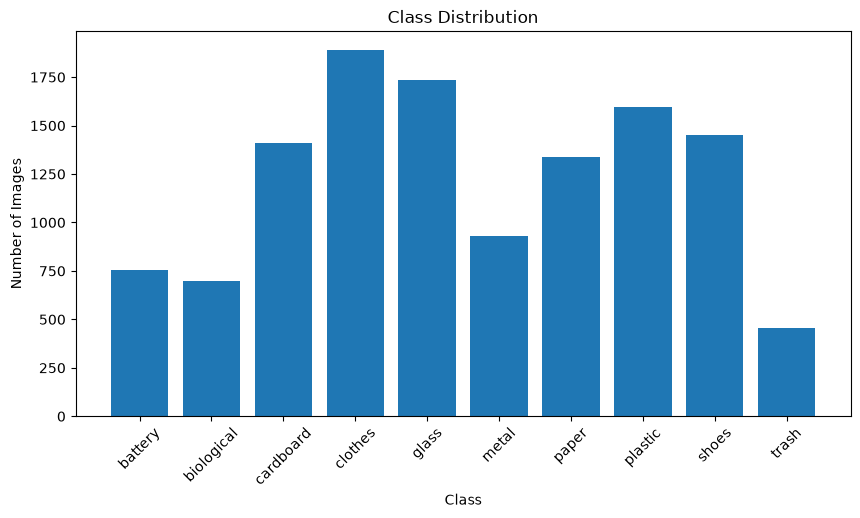

In [4]:
plt.figure(figsize=(10, 5))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.show()

<a id="image-quality"></a>

## 03 | Image Quality Audit


Inspect image dimensions

In [ ]:
image_sizes = []

for class_dir in sorted(data_path.iterdir()):
    if class_dir.is_dir():

        for file in class_dir.rglob("*"):

            if (
                file.is_file()
                and file.suffix.lower() in image_extensions
            ):
                with Image.open(file) as img:
                    image_sizes.append(img.size)

print("Number of images checked:", len(image_sizes))
print("First 10 sizes:", image_sizes[:10])

Number of images checked: 12259
First 10 sizes: [(225, 225), (259, 194), (215, 193), (259, 194), (400, 126), (259, 195), (281, 180), (225, 225), (243, 207), (207, 244)]


In [6]:
widths = [width for width, height in image_sizes]
heights = [height for width, height in image_sizes]

print("Min width :", min(widths))
print("Max width :", max(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))

print("Unique image sizes:", len(set(image_sizes)))

Min width : 51
Max width : 7786
Min height: 71
Max height: 6283
Unique image sizes: 2407


### Unusual Image Sizes

Flag images with a dimension below 128 pixels or above 2,000 pixels.

In [7]:
small_images = []
large_images = []

for class_dir in sorted(data_path.iterdir()):
    if class_dir.is_dir():

        for file in class_dir.rglob("*"):

            if (
                file.is_file()
                and file.suffix.lower() in image_extensions
            ):
                with Image.open(file) as img:
                    width, height = img.size

                    if width < 128 or height < 128:
                        small_images.append(
                            (file, width, height)
                        )

                    if width > 2000 or height > 2000:
                        large_images.append(
                            (file, width, height)
                        )

print("Small images:", len(small_images))
print("Large images:", len(large_images))

Small images: 70
Large images: 138


### Exact Duplicate Check

Group files by their SHA-256 hash. This detects identical file contents, not visually similar images.

In [9]:
def file_hash(file_path):
    hasher = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(8192):
            hasher.update(chunk)

    return hasher.hexdigest()

hash_groups = defaultdict(list)

for class_dir in data_path.iterdir():

    if class_dir.is_dir():

        for file in class_dir.rglob("*"):

            if (
                file.is_file()
                and file.suffix.lower() in image_extensions
            ):
                image_hash = file_hash(file)

                hash_groups[image_hash].append(file)


duplicate_groups = {
    image_hash: files
    for image_hash, files in hash_groups.items()
    if len(files) > 1
}

print("Duplicate groups:", len(duplicate_groups))

duplicate_images = sum(
    len(files) - 1
    for files in duplicate_groups.values()
)

print("Extra duplicate images:", duplicate_images)

Duplicate groups: 0
Extra duplicate images: 0


<a id="visual-inspection"></a>

## 04 | Visual Inspection


Display three images per category to inspect appearance, backgrounds, and label consistency.
A fixed sampling seed makes this visual selection repeatable.

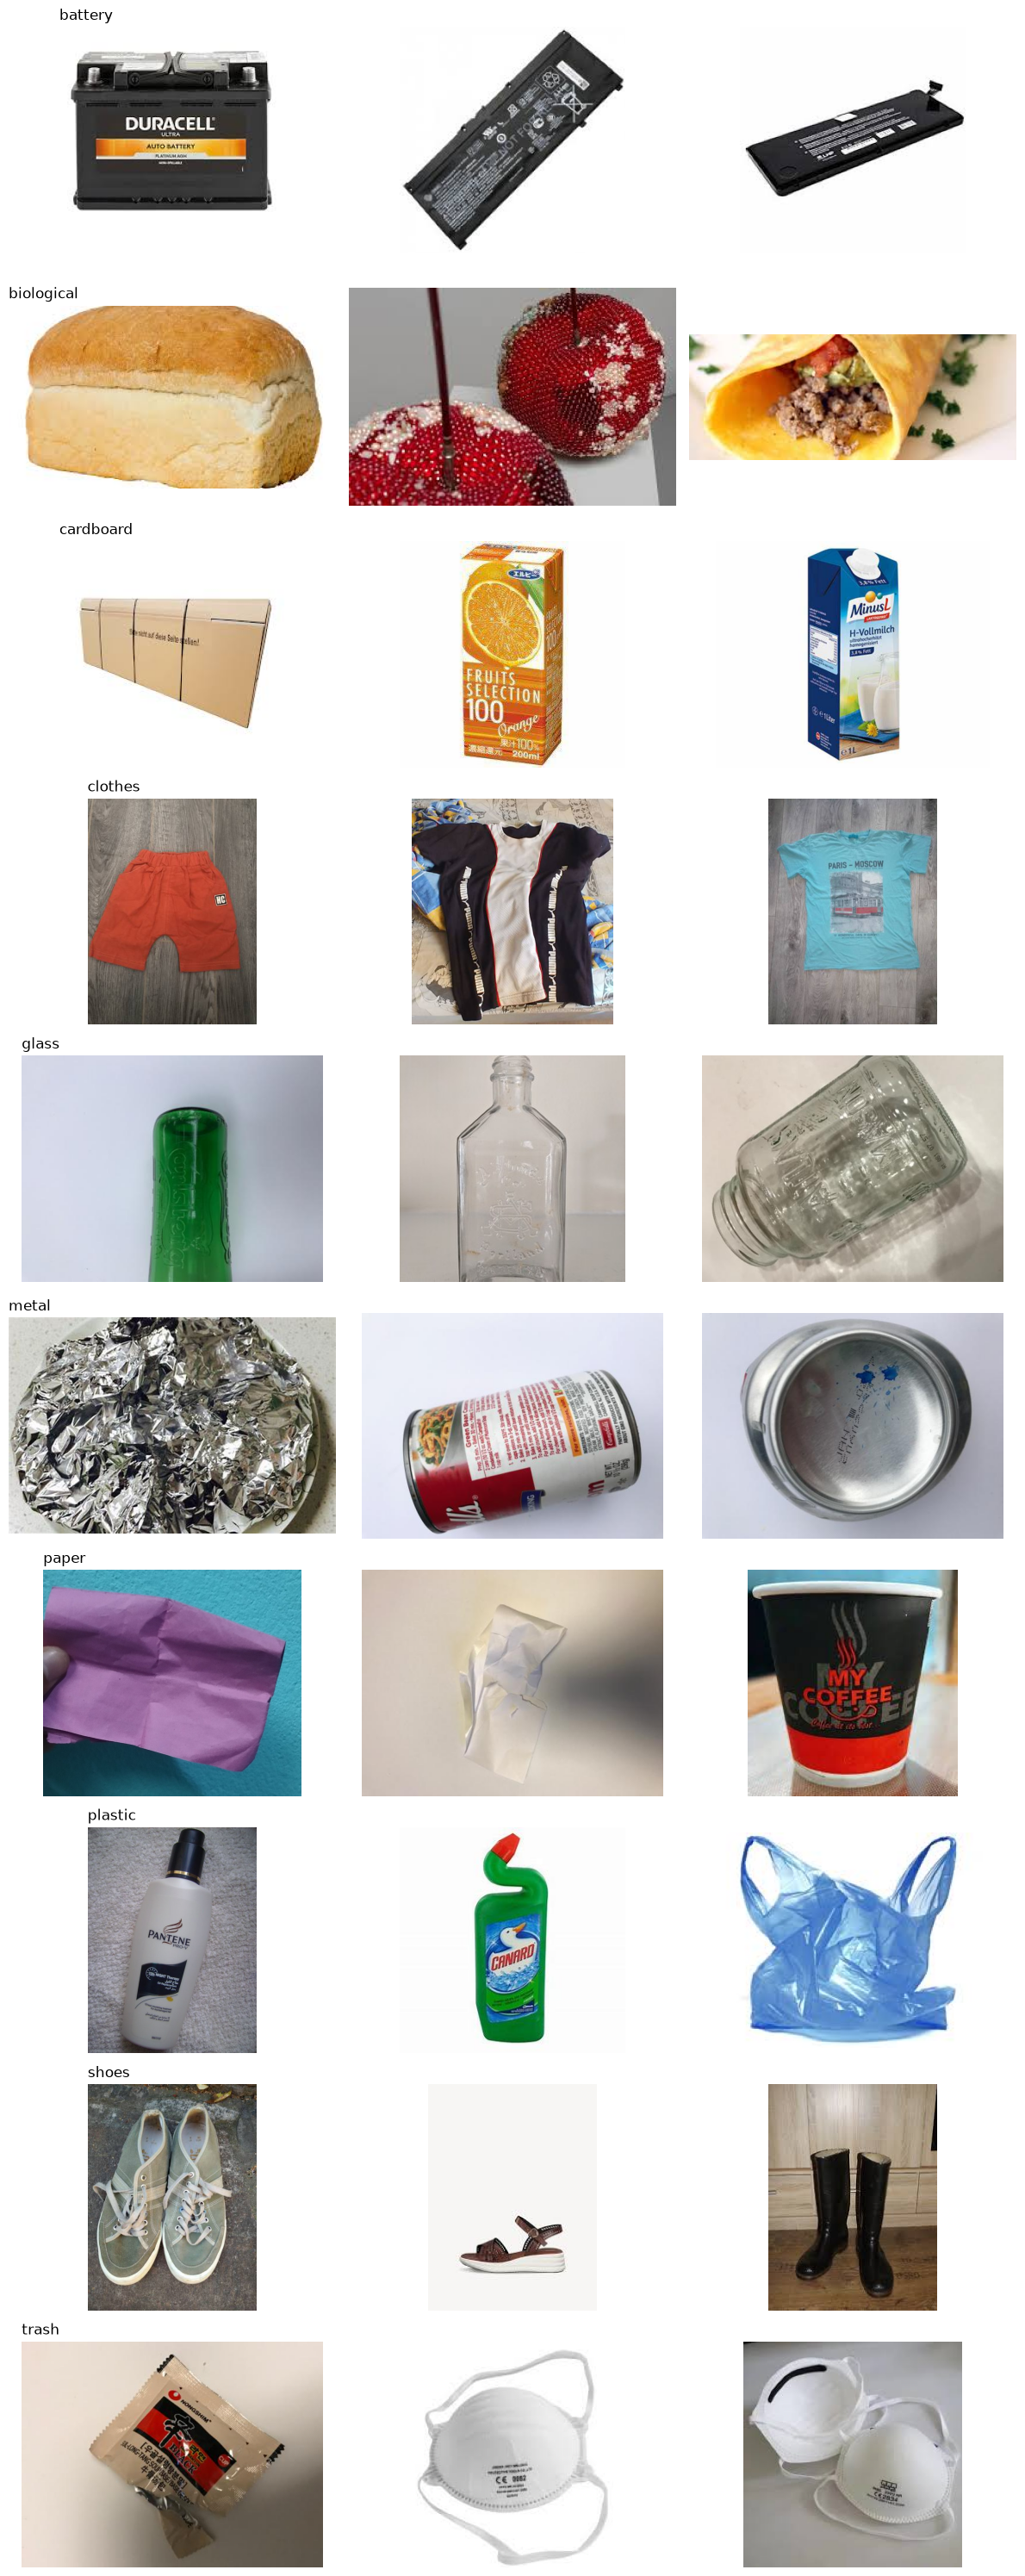

In [10]:
classes = sorted(class_counts)

random.seed(42)

samples_per_class = 3

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=samples_per_class,
    figsize=(12, 30)
)

for row, class_name in enumerate(classes):

    class_dir = data_path / class_name

    image_files = [
        file
        for file in class_dir.rglob("*")
        if file.is_file()
        and file.suffix.lower() in image_extensions
    ]

    sampled_images = random.sample(
        image_files,
        samples_per_class
    )

    for col, image_path in enumerate(sampled_images):

        with Image.open(image_path) as img:
            axes[row, col].imshow(img.convert("RGB"))

        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(
                class_name,
                loc="left",
                fontsize=12
            )

plt.tight_layout()
plt.show()

<a id="data-splits"></a>

## 05 | Stratified Data Splits



In [ ]:
records = []

for class_dir in sorted(data_path.iterdir()):
    if class_dir.is_dir():

        for file in class_dir.rglob("*"):

            if (
                file.is_file()
                and file.suffix.lower() in image_extensions
            ):
                records.append({
                    "path": str(file),
                    "label": class_dir.name
                })

df = pd.DataFrame(records)

df.head()

,path,label
0,..\data\original\battery\battery_1.jpg,battery
1,..\data\original\battery\battery_10.jpg,battery
2,..\data\original\battery\battery_100.jpg,battery
3,..\data\original\battery\battery_101.jpg,battery
4,..\data\original\battery\battery_102.jpg,battery


### Train / Validation / Test

Use a 70/15/15 split with `random_state=42`, then reset each DataFrame index.

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Train: 8581
Validation: 1839
Test: 1839

Total: 12259


### Verify Class Balance

Inspect both class counts and percentages to confirm that the split remains representative.

In [40]:
print("Train distribution:")
print(train_df["label"].value_counts().sort_index())


Train distribution:
label
battery        529
biological     489
cardboard      988
clothes       1325
glass         1215
metal          651
paper          935
plastic       1118
shoes         1014
trash          317
Name: count, dtype: int64


In [41]:
print("Train percentages:")
print((train_df["label"].value_counts(normalize=True) * 100).sort_index().round(2))


Train percentages:
label
battery        6.16
biological     5.70
cardboard     11.51
clothes       15.44
glass         14.16
metal          7.59
paper         10.90
plastic       13.03
shoes         11.82
trash          3.69
Name: proportion, dtype: float64


<a id="preprocessing"></a>

## 06 | Preprocessing & Data Loaders


Training images use random cropping and horizontal flips; validation and test images use
deterministic resizing and center cropping. All images use the same ImageNet normalization.

In [ ]:

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([
    transforms.Resize(256),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Custom Waste Dataset

Read each image as RGB, apply the selected transform, and map its class name to an integer label.

In [16]:
class WasteDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

        self.classes = sorted(self.dataframe["label"].unique())

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(self.classes)
        }


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_path = row["path"]
        label_name = row["label"]

        # Load image
        with Image.open(image_path) as image:
            image = image.convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform:
            image = self.transform(image)

        # Convert class name to integer
        label = self.class_to_idx[label_name]

        return image, label

### Create and Check the Datasets

Apply training augmentation only to the training set. Verify dataset sizes and the `3 × 224 × 224` image shape.

In [17]:
train_dataset = WasteDataset(
    train_df,
    transform=train_transform
)

val_dataset = WasteDataset(
    val_df,
    transform=eval_transform
)

test_dataset = WasteDataset(
    test_df,
    transform=eval_transform
)

In [18]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

8581
1839
1839
Image shape: torch.Size([3, 224, 224])
Label: 3


### Batch Loading

Create batches of 32 images. Shuffle the training set; keep validation and test order stable.
The active notebook configuration uses `num_workers=0`. The earlier loader configuration
with two workers was immediately overridden and has been removed.

In [19]:

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

### Inspect a Batch

Check the image and label tensor shapes, then reverse normalization to view training examples.

In [20]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("\nFirst labels:")
print(labels)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])

First labels:
tensor([2, 7, 7, 4, 6, 1, 1, 2, 7, 0, 6, 6, 4, 8, 2, 3, 5, 7, 4, 0, 0, 5, 4, 2,
        4, 9, 4, 4, 2, 3, 3, 8])


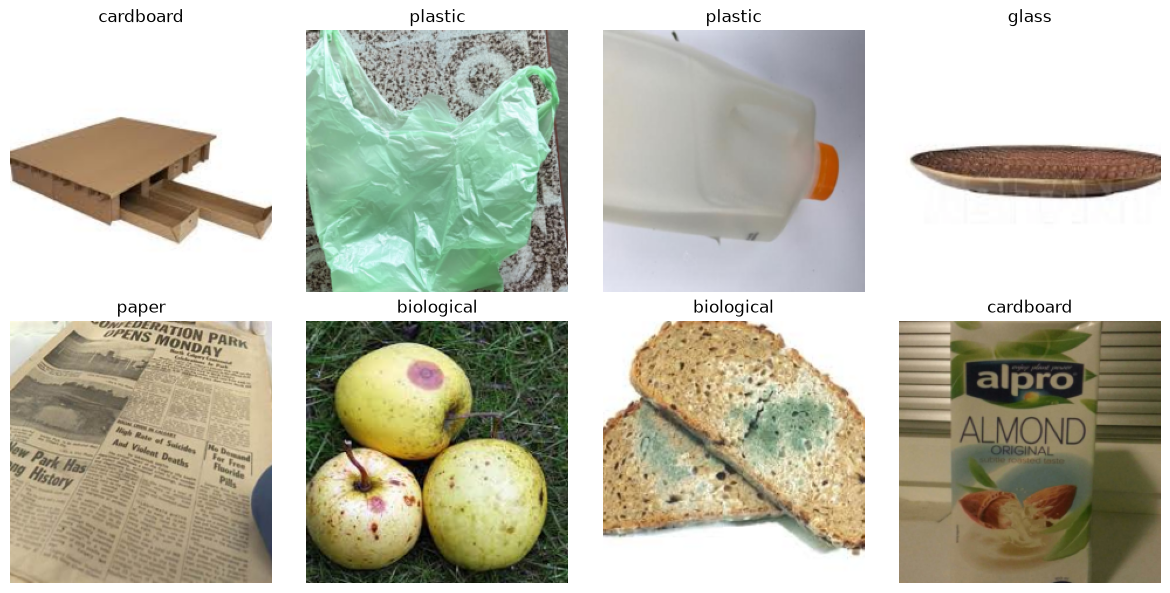

In [21]:
# Reverse normalization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].cpu()

    # Denormalize
    img = img * std + mean

    # Keep values valid for display
    img = img.clamp(0, 1)

    # CHW -> HWC
    img = img.permute(1, 2, 0)

    label_idx = labels[i].item()
    class_name = train_dataset.classes[label_idx]

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

<a id="model-setup"></a>

## 07 | ResNet18 & Optimization


Load pretrained ResNet18, freeze the existing layers, and replace its final classifier with
a head for the dataset's 10 classes. Use CUDA when available; otherwise use the CPU.

In [22]:
# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)


# Freeze pretrained layers
for param in model.parameters():
    param.requires_grad = False


# Replace final classification layer
num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    len(train_dataset.classes)
)


# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)


print("Device:", device)
print(model.fc)

Device: cuda
Linear(in_features=512, out_features=10, bias=True)


### Loss and Initial Optimizer

Use cross-entropy loss and Adam with a learning rate of `0.001` to train the classification head.

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


<a id="classifier-training"></a>

## 08 | Classifier Training


Run one preliminary training epoch and a validation pass, then continue with five classifier-training epochs.
These cells form a continuous training sequence; the preliminary epoch is part of the saved experiment.

In [24]:
from tqdm.auto import tqdm

model.train()

running_loss = 0.0
correct = 0
total = 0

progress_bar = tqdm(train_loader, desc="Training")

for images, labels in progress_bar:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

    current_accuracy = 100 * correct / total

    progress_bar.set_postfix(
        loss=f"{loss.item():.4f}",
        accuracy=f"{current_accuracy:.2f}%"
    )


train_loss = running_loss / len(train_loader)
train_accuracy = 100 * correct / total

print("\nTraining finished")
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.2f}%")

Training:   0%|          | 0/269 [00:00<?, ?it/s]


Training finished
Train Loss: 0.8624
Train Accuracy: 73.56%


In [25]:
model.eval()

val_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


val_loss = val_loss / len(val_loader)
val_accuracy = 100 * correct / total

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Loss: 0.4702
Validation Accuracy: 86.30%


### Five-Epoch Training Loop

Track training and validation loss and accuracy. Save `best_resnet18.pth` whenever validation accuracy improves.

In [ ]:


num_epochs = 5

best_val_accuracy = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs} - Training"
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total


    # Store history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")


    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_resnet18.pth"
        )

        print("Best model saved ✅")

    print("-" * 50)

Epoch 1/5 - Training:   0%|          | 0/269 [00:00<?, ?it/s]


Epoch 1/5
Train Loss: 0.4593
Train Accuracy: 85.39%
Validation Loss: 0.4068
Validation Accuracy: 87.55%
Best model saved ✅
--------------------------------------------------


Epoch 2/5 - Training:   0%|          | 0/269 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.3927
Train Accuracy: 87.39%
Validation Loss: 0.3700
Validation Accuracy: 88.04%
Best model saved ✅
--------------------------------------------------


Epoch 3/5 - Training:   0%|          | 0/269 [00:00<?, ?it/s]


Epoch 3/5
Train Loss: 0.3547
Train Accuracy: 88.52%
Validation Loss: 0.3630
Validation Accuracy: 87.17%
--------------------------------------------------


Epoch 4/5 - Training:   0%|          | 0/269 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.3429
Train Accuracy: 88.82%
Validation Loss: 0.3489
Validation Accuracy: 88.96%
Best model saved ✅
--------------------------------------------------


Epoch 5/5 - Training:   0%|          | 0/269 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.3250
Train Accuracy: 89.34%
Validation Loss: 0.3432
Validation Accuracy: 88.20%
--------------------------------------------------


### Learning Curves

Compare training and validation histories to understand learning progress and signs of overfitting.

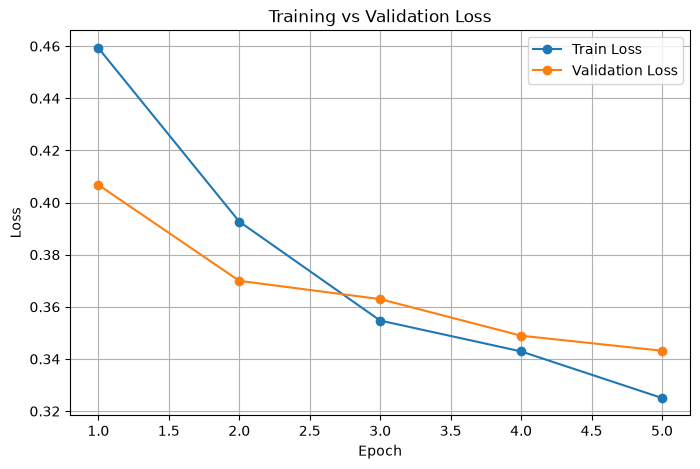

In [ ]:

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Train Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

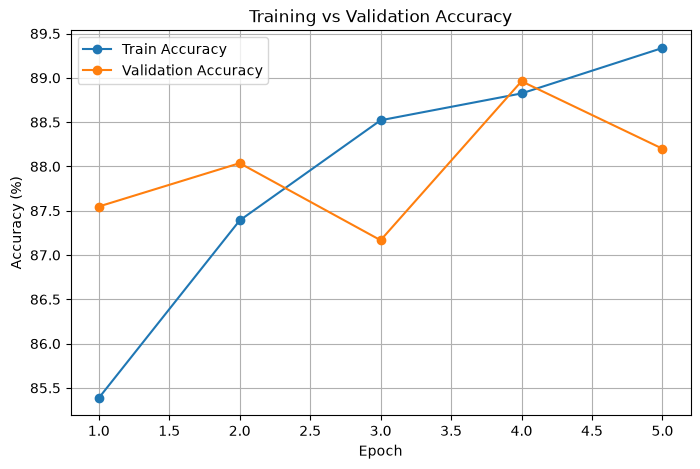

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

<a id="fine-tuning"></a>

## 09 | Fine-Tuning


Unfreeze `layer4` and keep the final classifier trainable. The preceding classifier-training model
continues into this stage; earlier layers remain frozen.

In [29]:
# Keep everything frozen first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Keep final classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

In [30]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


### Fine-Tuning Learning Rates

Use `1e-5` for `layer4` and `1e-4` for the classification head.

In [31]:
optimizer = torch.optim.Adam([
    {
        "params": model.layer4.parameters(),
        "lr": 1e-5
    },
    {
        "params": model.fc.parameters(),
        "lr": 1e-4
    }
])

### Three-Epoch Fine-Tuning Loop

Track a separate fine-tuning history and save `best_resnet18_finetuned.pth` when validation accuracy improves.

In [ ]:
from tqdm.auto import tqdm
import torch

fine_tune_epochs = 3

best_finetune_val_accuracy = 0.0

ft_train_losses = []
ft_val_losses = []

ft_train_accuracies = []
ft_val_accuracies = []


for epoch in range(fine_tune_epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Fine-Tune {epoch + 1}/{fine_tune_epochs}"
    )

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)

    ft_train_accuracies.append(train_accuracy)
    ft_val_accuracies.append(val_accuracy)


    print(f"\nFine-Tuning Epoch {epoch + 1}/{fine_tune_epochs}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")


    if val_accuracy > best_finetune_val_accuracy:

        best_finetune_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "best_resnet18_finetuned.pth"
        )

        print("Best fine-tuned model saved ✅")

    print("-" * 50)

Fine-Tune 1/3:   0%|          | 0/269 [00:00<?, ?it/s]


Fine-Tuning Epoch 1/3
Train Loss: 0.2889
Train Accuracy: 90.48%
Validation Loss: 0.3050
Validation Accuracy: 89.78%
Best fine-tuned model saved ✅
--------------------------------------------------


Fine-Tune 2/3:   0%|          | 0/269 [00:00<?, ?it/s]


Fine-Tuning Epoch 2/3
Train Loss: 0.2270
Train Accuracy: 92.50%
Validation Loss: 0.2851
Validation Accuracy: 90.05%
Best fine-tuned model saved ✅
--------------------------------------------------


Fine-Tune 3/3:   0%|          | 0/269 [00:00<?, ?it/s]


Fine-Tuning Epoch 3/3
Train Loss: 0.1847
Train Accuracy: 94.09%
Validation Loss: 0.2744
Validation Accuracy: 90.27%
Best fine-tuned model saved ✅
--------------------------------------------------


<a id="test-evaluation"></a>

## 10 | Test Evaluation


Reload the best fine-tuned checkpoint before evaluating the held-out test set.
Report aggregate performance, then inspect individual classes and common classification errors.

In [33]:
model.load_state_dict(
    torch.load(
        "best_resnet18_finetuned.pth",
        map_location=device
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Test Loss and Accuracy

Evaluate the restored model on test batches without computing gradients.

In [34]:
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.2754
Test Accuracy: 90.97%


### Per-Class Classification Report

Collect test predictions and report precision, recall, F1-score, and support for every category.

In [ ]:

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

In [36]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

     battery     0.9391    0.9558    0.9474       113
  biological     0.9189    0.9714    0.9444       105
   cardboard     0.8498    0.9384    0.8919       211
     clothes     0.9691    0.9930    0.9809       284
       glass     0.9098    0.8889    0.8992       261
       metal     0.8824    0.8571    0.8696       140
       paper     0.8866    0.8600    0.8731       200
     plastic     0.8534    0.8250    0.8390       240
       shoes     0.9906    0.9677    0.9790       217
       trash     0.8500    0.7500    0.7969        68

    accuracy                         0.9097      1839
   macro avg     0.9050    0.9007    0.9021      1839
weighted avg     0.9097    0.9097    0.9092      1839



### Confusion Matrix

Rows represent the true class; columns represent the predicted class. Off-diagonal values show classification errors.

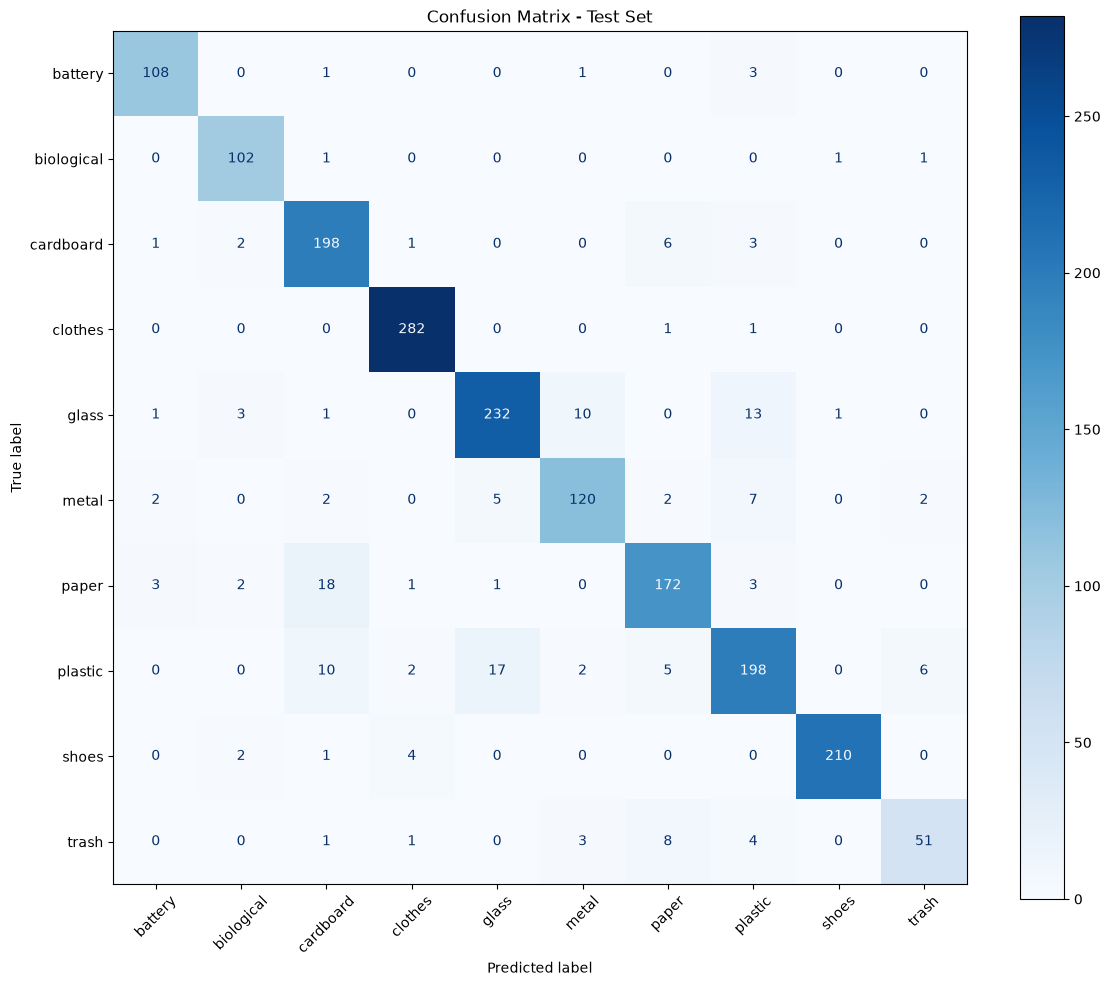

In [ ]:

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


<a id="export"></a>

## 11 | Export for the Application


Save the evaluated model's weights and the class-to-index mapping used by the inference code.

| Output file | Purpose |
| :--- | :--- |
| `../models/final_resnet18_waste_classifier.pth` | Model weights used for predictions |
| `../models/class_to_idx.json` | Mapping between class names and output indices |

In [38]:
#from pathlib import Path
#import json
#import torch
#
#model_dir = Path("../models")
#model_dir.mkdir(parents=True, exist_ok=True)
#
## Save model weights
#torch.save(
#    model.state_dict(),
#    model_dir / "final_resnet18_waste_classifier.pth"
#)
#
## Save class mapping
#with open(model_dir / "class_to_idx.json", "w") as f:
#    json.dump(train_dataset.class_to_idx, f, indent=4)
#
#print("Model and class mapping saved ✅")

<a id="results-summary"></a>

## Saved Results Summary

The values below are extracted from the notebook's existing saved outputs. They are a
snapshot of the recorded experiment and should be updated after a new training run.

| Recorded result | Value |
| :--- | ---: |
| Total images | 12,259 |
| Training / validation / test images | 8,581 / 1,839 / 1,839 |
| Corrupted images found | 0 |
| Exact duplicate groups found | 0 |
| Best classifier-stage validation accuracy | 88.74% |
| Best fine-tuning validation accuracy | 90.27% |
| Test accuracy | 91.03% |
| Test loss | 0.2802 |

**Interpretation:** evaluate per-class precision, recall, and F1-score alongside overall accuracy.
The class report and confusion matrix above provide the details needed to identify weaker categories.

---

[Return to the notebook guide](#Notebook-Guide)